### Filtering autopilot disengaged responses
This notebook is to visualize our current data from A998 to detect whether we have rapid guesses in our answers form disengaged students that are contaminating the analysis. 

If that is the case, we will define a datadriven criteria to filter them out and define it in an `autopilot_filtering.py` function so all analysis can use it when necessary.

The method taken is the CAF (Conditional Accuracy Function). Responses are grouped into small response-time windows, and the mean accuracy within each window is plotted against response time. This allows us to examine how performance changes as a function of answering speed. If autopilot responding is present, we expect to observe a region at very short response times with substantially lower accuracy, followed by a transition toward higher and more stable accuracy as response time increases.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Paths
# ============================================================

HERE = Path.cwd()

# Find repository root
ROOT = HERE
while not (ROOT / "databricks_connector.py").exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError(
            "databricks_connector.py not found in any parent directory"
        )
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

from cached_query import cached_query


# Local notebook folders
QUERY_DIR = HERE / "queries"
CACHE_DIR = HERE / "cache"
PLOTS_DIR = HERE / "plots"

CACHE_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)


# ============================================================
# Load data
# ============================================================

SQL_PATH = QUERY_DIR / "a998_sample_data.sql"

a998_raw = cached_query(
    SQL_PATH,
    CACHE_DIR
)

print(f"Loaded {len(a998_raw):,} attempts")
print(a998_raw.shape)
display(a998_raw.head())

Loaded 16,894,141 attempts
(16894141, 14)


,region,academic_year_id,classroom_course_age,student_uuid,session_id,activity_pack,statement_id,statement_idx,operation_raw,factor_1,factor_2,statement_result,is_correct,rt_seconds
0,BR,BR_2024,8.0,011E29727355495B8AFB1B6EF767EFD7,historic-4937492-L,14,a0f0b1d5eca0c9c4f789569a22a662c2,0,6×5,6,5,Correct,1,24.433
1,BR,BR_2024,8.0,011E29727355495B8AFB1B6EF767EFD7,historic-4937492-L,14,a6414fb2005ccda602bad771a5f2dee7,1,4×2,4,2,Incorrect,0,3.811
2,BR,BR_2024,8.0,011E29727355495B8AFB1B6EF767EFD7,historic-4937492-L,14,53997994f0458cf91a90837860031a6d,2,7×5,7,5,Correct,1,11.304
3,BR,BR_2024,8.0,011E29727355495B8AFB1B6EF767EFD7,historic-4937492-L,14,ad08ecaff280d68a59a084df79c7cc9a,3,8×5,8,5,Correct,1,8.039
4,BR,BR_2024,8.0,011E29727355495B8AFB1B6EF767EFD7,historic-4937492-L,14,1e230648d2e60d39dc7fe58189197dda,4,5×2,5,2,Correct,1,3.030


In [2]:
# ============================================================
# Parameters
# ============================================================

BIN_WIDTH = 0.05           # 50 ms RT windows
MAX_RT_PLOT = 30.0          # only plot first 5 seconds
MIN_ATTEMPTS_PER_BIN = 10

# ============================================================
# Basic cleaning
# ============================================================

a998 = a998_raw[
    a998_raw["rt_seconds"].notna()
    & a998_raw["is_correct"].notna()
    & a998_raw["classroom_course_age"].notna()
    & (a998_raw["rt_seconds"] >= 0)
].copy()


# ============================================================
# Create RT windows
# ============================================================

# Example:
# 0.00–0.05 -> centre 0.025
# 0.05–0.10 -> centre 0.075
# etc.

a998["rt_bin"] = (
    np.floor(a998["rt_seconds"] / BIN_WIDTH) * BIN_WIDTH
)

a998["rt_bin_center"] = (
    a998["rt_bin"] + BIN_WIDTH / 2
)


# ============================================================
# Accuracy by RT window and age
# ============================================================

rt_accuracy = (
    a998
    .groupby(
        ["classroom_course_age", "rt_bin_center"],
        observed=True
    )
    .agg(
        accuracy=("is_correct", "mean"),
        n_attempts=("is_correct", "size")
    )
    .reset_index()
)


# Drop very sparse bins
rt_accuracy = rt_accuracy[
    rt_accuracy["n_attempts"] >= MIN_ATTEMPTS_PER_BIN
].copy()

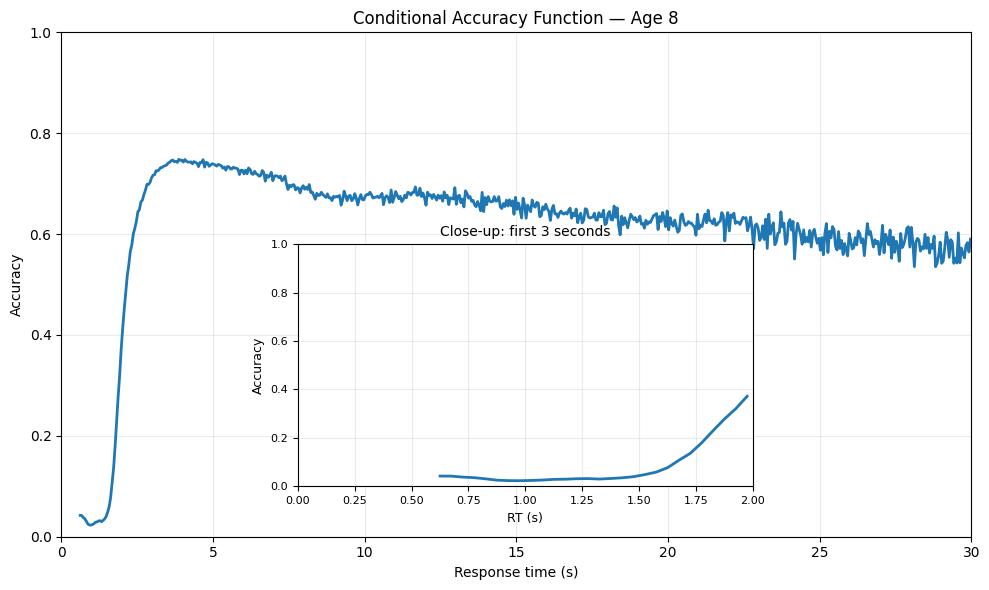

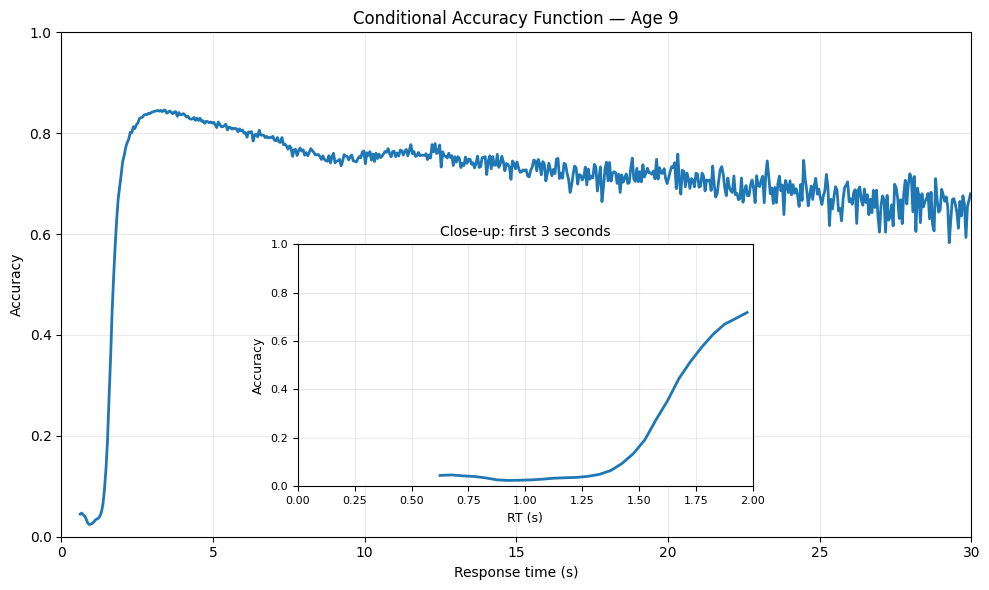

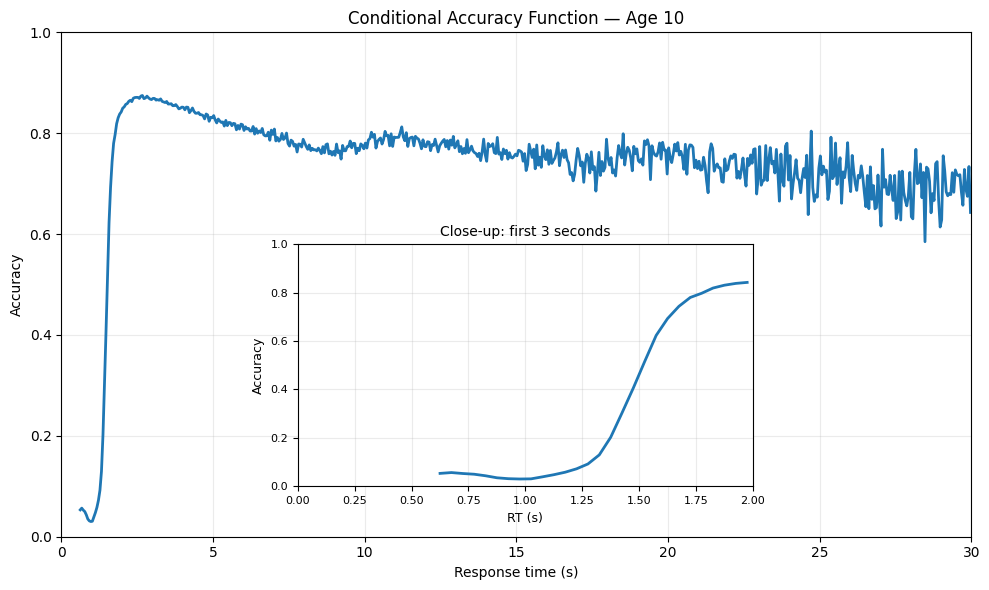

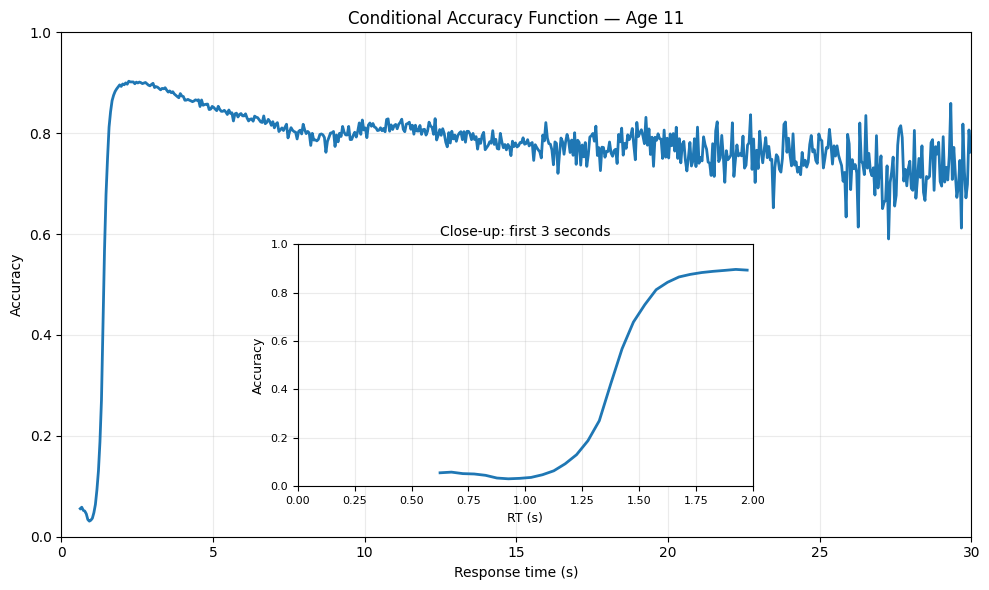

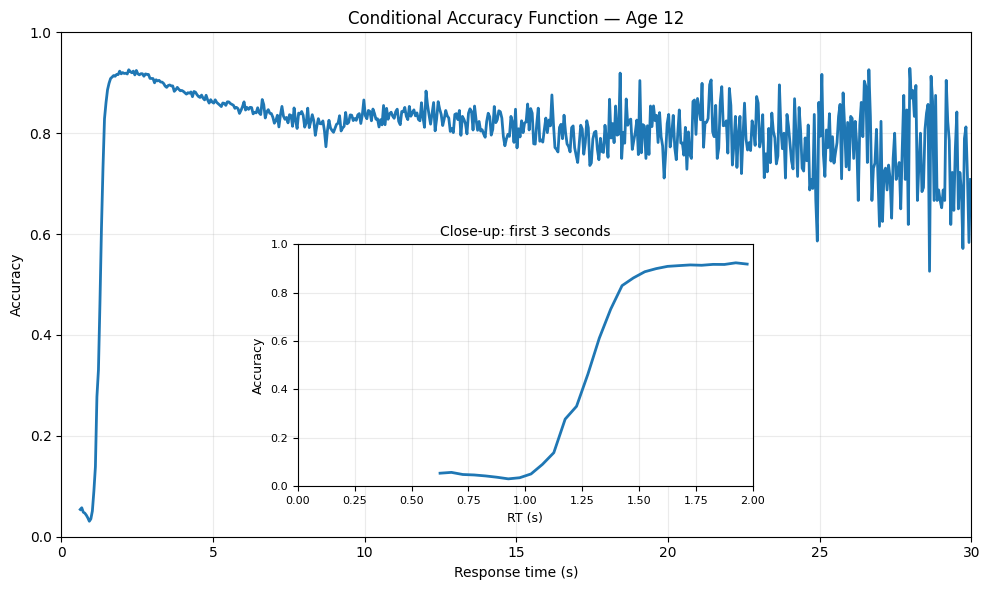

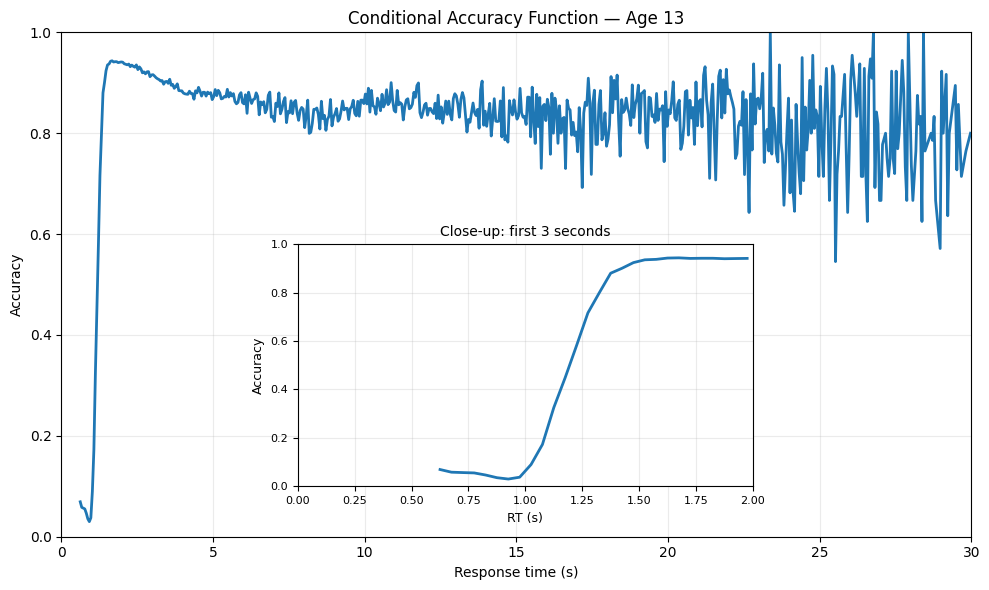

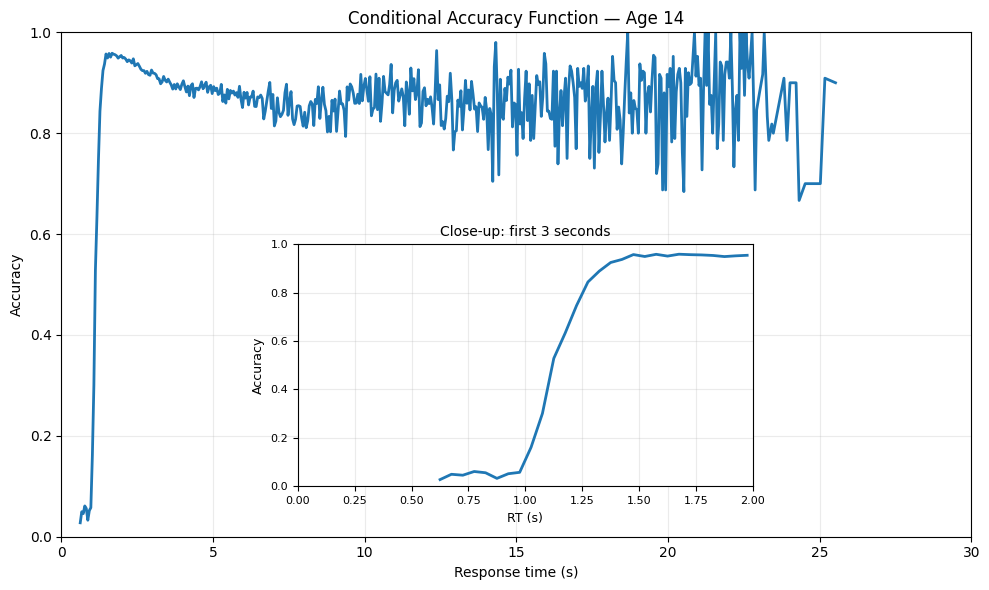

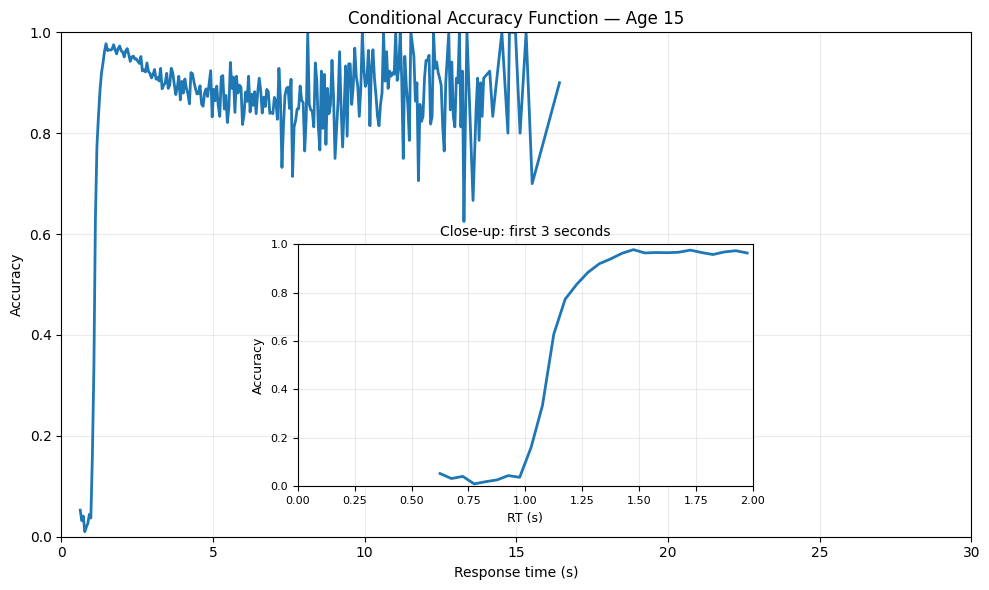

In [3]:
# ============================================================
# Plot one figure per age + close-up of first 3 seconds
# ============================================================

ages = np.arange(8, 16)

CLOSEUP_RT = 2.0


for age in ages:

    plot_df = rt_accuracy[
        (rt_accuracy["classroom_course_age"] == age)
        & (rt_accuracy["rt_bin_center"] <= MAX_RT_PLOT)
    ].copy()

    fig, ax = plt.subplots(figsize=(10, 6))

    # --------------------------------------------------------
    # Main plot
    # --------------------------------------------------------

    ax.plot(
        plot_df["rt_bin_center"],
        plot_df["accuracy"],
        linewidth=2
    )

    ax.set_title(
        f"Conditional Accuracy Function — Age {age}"
    )

    ax.set_xlabel("Response time (s)")
    ax.set_ylabel("Accuracy")

    ax.set_xlim(0, MAX_RT_PLOT)
    ax.set_ylim(0, 1)

    ax.grid(alpha=0.25)


    # --------------------------------------------------------
    # Close-up: first 3 seconds
    # --------------------------------------------------------

    closeup_df = plot_df[
        plot_df["rt_bin_center"] <= CLOSEUP_RT
    ]

    ax_zoom = ax.inset_axes(
        [0.26, 0.10, 0.50, 0.48]
        # [x_position, y_position, width, height]
        # coordinates relative to main axes
    )

    ax_zoom.plot(
        closeup_df["rt_bin_center"],
        closeup_df["accuracy"],
        linewidth=2
    )

    ax_zoom.set_xlim(0, CLOSEUP_RT)
    ax_zoom.set_ylim(0, 1)

    ax_zoom.set_title(
        "Close-up: first 3 seconds",
        fontsize=10
    )

    ax_zoom.set_xlabel(
        "RT (s)",
        fontsize=9
    )

    ax_zoom.set_ylabel(
        "Accuracy",
        fontsize=9
    )

    ax_zoom.tick_params(
        axis="both",
        labelsize=8
    )

    ax_zoom.grid(alpha=0.25)


    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    plt.tight_layout()

    fig.savefig(
        PLOTS_DIR / f"caf_age_{age}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

WOW! We have indeed found there are tons of answers of short RT that are incorrect! If our hypothesis is true, the distribution of RT should contain two regions, one where all rapids guesses ansers fast, and a slower region for students actually recalling the answer. Let's check!

Pooled ages 11-15: 4,216,518 attempts


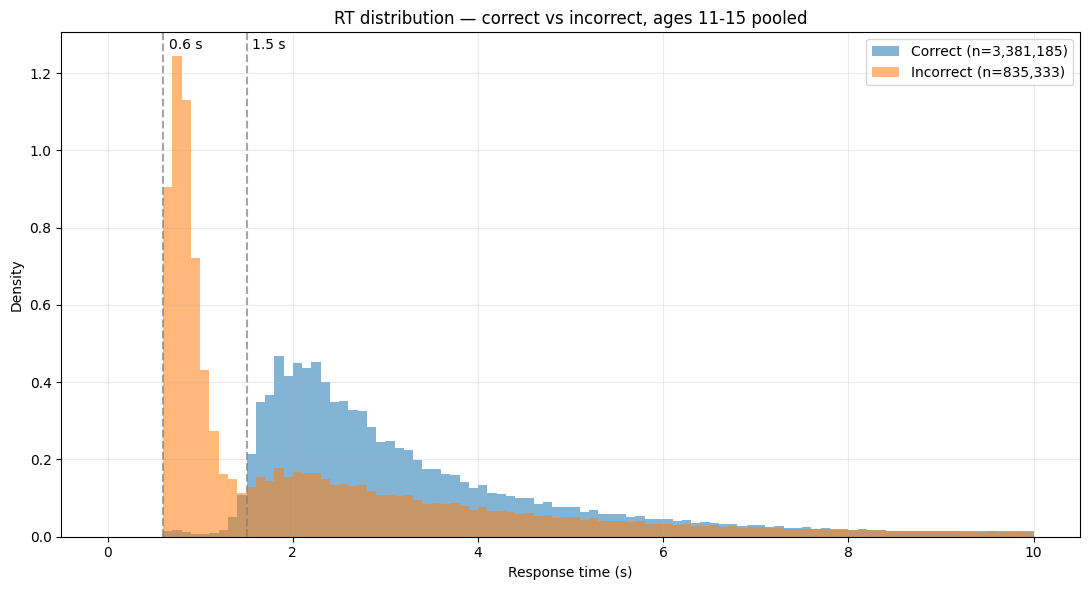

In [4]:
# ============================================================
# Pooled overview: RT histograms, all ages together
#
# Same data as the per-age panels below, but with the ages in
# AGES_POOLED collapsed into a single pair of histograms, so the
# two regions (rapid guessing vs actual retrieval) can be read
# off one plot.
# ============================================================

# AGES_POOLED = np.arange(8, 16)          # 6 and 7 are data errors, excluded
AGES_POOLED = np.arange(11, 16)

HIST_BIN_WIDTH = 0.1
MAX_RT_HIST_POOLED = 10.0
MIN_ATTEMPTS_PER_BIN = 0

MARKER_LINES = [0.6, 1.5]               # seconds

bin_edges = np.arange(
    0,
    MAX_RT_HIST_POOLED + HIST_BIN_WIDTH,
    HIST_BIN_WIDTH
)

# Label built from AGES_POOLED so it cannot drift from what is plotted
AGES_LABEL = f"ages {AGES_POOLED.min()}-{AGES_POOLED.max()}"


pooled = a998[
    a998["classroom_course_age"].isin(AGES_POOLED)
    & (a998["rt_seconds"] <= MAX_RT_HIST_POOLED)
]

print(f"Pooled {AGES_LABEL}: {len(pooled):,} attempts")


series = {
    "Correct": {
        "rt": pooled.loc[pooled["is_correct"] == 1, "rt_seconds"],
        "color": "#1f77b4",
    },
    "Incorrect": {
        "rt": pooled.loc[pooled["is_correct"] == 0, "rt_seconds"],
        "color": "#ff7f0e",
    },
}


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

for label, spec in series.items():

    ax.hist(
        spec["rt"],
        bins=bin_edges,
        density=True,
        alpha=0.55,
        color=spec["color"],
        label=f"{label} (n={len(spec['rt']):,})"
    )


# ------------------------------------------------------------
# Candidate thresholds
# ------------------------------------------------------------

for x in MARKER_LINES:

    ax.axvline(
        x,
        linestyle="--",
        linewidth=1.5,
        color="grey",
        alpha=0.7
    )

    ax.annotate(
        f"{x} s",
        xy=(x, 1.0),
        xycoords=("data", "axes fraction"),
        xytext=(4, -12),
        textcoords="offset points",
        fontsize=10
    )


ax.set_xlabel("Response time (s)")
ax.set_ylabel("Density")

ax.set_title(
    f"RT distribution — correct vs incorrect, {AGES_LABEL} pooled"
)

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()

fig.savefig(
    PLOTS_DIR / "rt_histogram_pooled_ages.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

In [5]:
# ------------------------------------------------------------
# Diagnostics on the A998 RAW frame. Whichever frame this points
# at is the one the numbers describe -- keep it explicit, the
# Fluency frame lives under fluency_raw further down.
# ------------------------------------------------------------

sub = a998_raw.loc[a998_raw["rt_seconds"].notna(), "rt_seconds"]

print("min:", sub.min())
print("== 0 exactament:", (sub == 0).sum())
print("< 0:", (sub < 0).sum())

# resolucio: quants valors diferents hi ha per sota d'1 s?
print("valors unics < 1 s:", sub[sub < 1].nunique())
print(sub[sub < 1].value_counts().head(20))

# la forma del sub-segon, i si l'statement 0 la contamina
print(
    a998_raw.loc[a998_raw["rt_seconds"] < 1]
      .assign(
          bin=lambda d: (d["rt_seconds"] // 0.05) * 0.05,
          is_first=lambda d: d["statement_idx"] == 0,
      )
      .groupby(["bin", "is_first"])
      .size()
      .unstack(fill_value=0)
)

min: 0.083
== 0 exactament: 0
< 0: 0
valors unics < 1 s: 427
rt_seconds
0.700    77780
0.800    77479
0.733    71014
0.750    65579
0.833    61339
0.683    60117
0.900    58930
0.850    56598
0.766    54506
0.783    53291
0.667    52326
0.767    52209
0.666    51429
0.716    49044
0.650    46207
0.866    46052
0.717    44888
0.867    42392
0.933    42130
0.816    41692
Name: count, dtype: int64
is_first   False
bin             
0.05           2
0.10           3
0.15           5
0.20           5
0.25           6
0.30           3
0.40           1
0.45           3
0.50           4
0.55           5
0.60      157088
0.65      466004
0.70      467346
0.75      387783
0.80      504513
0.85      379843
0.90      296523
0.95      223943


In [6]:
import numpy as np

u = np.sort(sub[sub < 1].unique())
print(pd.Series(np.round(np.diff(u), 4)).value_counts().head(15))

for step in [0.05, 1/24, 1/30, 1/60]:
    on_grid = np.abs(a998_raw["rt_seconds"]/step - np.round(a998_raw["rt_seconds"]/step)) < 0.02
    print(f"pas {step:.4f}:")
    print(a998_raw.assign(on_grid=on_grid).groupby("region")["on_grid"].mean().round(3))

0.001    400
0.016      3
0.002      3
0.018      2
0.017      2
0.006      2
0.066      2
0.034      1
0.003      1
0.029      1
0.042      1
0.008      1
0.010      1
0.031      1
0.052      1
Name: count, dtype: int64
pas 0.0500:
region
BR       0.167
CL       0.161
CO-A     0.106
CO-B     0.164
EC-CO    0.142
EC-SI    0.149
ES       0.159
IT       0.124
MX       0.153
US       0.118
Name: on_grid, dtype: float64
pas 0.0417:
region
BR       0.097
CL       0.091
CO-A     0.065
CO-B     0.100
EC-CO    0.085
EC-SI    0.093
ES       0.091
IT       0.078
MX       0.088
US       0.069
Name: on_grid, dtype: float64
pas 0.0333:
region
BR       0.206
CL       0.191
CO-A     0.127
CO-B     0.278
EC-CO    0.168
EC-SI    0.221
ES       0.205
IT       0.196
MX       0.228
US       0.140
Name: on_grid, dtype: float64
pas 0.0167:
region
BR       0.213
CL       0.195
CO-A     0.126
CO-B     0.225
EC-CO    0.183
EC-SI    0.202
ES       0.206
IT       0.158
MX       0.194
US       0.143
Name: on_grid

In [7]:
import numpy as np

rt = a998_raw["rt_seconds"].to_numpy()

sel = (rt >= 0.05) & (rt < 5)
ms = np.round(rt[sel] * 1000).astype(int)
grid = np.arange(50, 5000)                 # tots els valors de 1 ms del rang

def near(x, step_ms):
    return np.abs(x - np.round(x / step_ms) * step_ms) <= 0.5

def report(name, test):
    obs = test(ms).mean()
    exp = test(grid).mean()                # el que donaria una distribució plana
    print(f"{name:24s} observat {100*obs:6.2f}%   esperat {100*exp:6.2f}%   x{obs/exp:.2f}")

report("100 ms",            lambda x: x % 100 == 0)
report("50 ms (no 100)",    lambda x: (x % 50 == 0) & (x % 100 != 0))
report("10 ms (no 50)",     lambda x: (x % 10 == 0) & (x % 50 != 0))
report("1/30 s (no 10 ms)", lambda x: near(x, 1000/30) & (x % 10 != 0))
report("1/24 s (no 10 ms)", lambda x: near(x, 1000/24) & (x % 10 != 0))
report("1/60 s (no 10 ms)", lambda x: near(x, 1000/60) & (x % 10 != 0))

100 ms                   observat   7.20%   esperat   0.99%   x7.27
50 ms (no 100)           observat   5.64%   esperat   1.01%   x5.58
10 ms (no 50)            observat   3.40%   esperat   8.00%   x0.42
1/30 s (no 10 ms)        observat  10.72%   esperat   2.00%   x5.36
1/24 s (no 10 ms)        observat   4.12%   esperat   2.00%   x2.06
1/60 s (no 10 ms)        observat  18.80%   esperat   4.00%   x4.70


In [8]:
dec  = ms % 50 == 0
g30  = near(ms, 1000/30) & ~dec
g24  = near(ms, 1000/24) & ~dec & ~g30
g60  = near(ms, 1000/60) & ~dec & ~g30 & ~g24

for name, mask, ref in [("decimal 50/100 ms", dec,  lambda x: x % 50 == 0),
                        ("1/30 s pur",        g30,  lambda x: near(x, 1000/30) & (x % 50 != 0)),
                        ("1/24 s pur",        g24,  lambda x: near(x, 1000/24) & (x % 50 != 0) & ~near(x, 1000/30)),
                        ("1/60 s pur",        g60,  lambda x: near(x, 1000/60) & (x % 50 != 0) & ~near(x, 1000/30) & ~near(x, 1000/24))]:
    print(f"{name:20s} x{mask.mean()/ref(grid).mean():.2f}")

# i de qui venen: cal el region de les mateixes files

reg = a998_raw["region"].to_numpy()[sel]
print(pd.crosstab(reg, np.where(dec, "decimal", np.where(g30, "1/30", "cap")), normalize="index").round(3))

decimal 50/100 ms    x6.42
1/30 s pur           x5.36
1/24 s pur           x1.05
1/60 s pur           x4.20
col_0   1/30    cap  decimal
row_0                       
BR     0.107  0.773    0.120
CL     0.105  0.777    0.118
CO-A   0.063  0.864    0.073
CO-B   0.156  0.706    0.138
EC-CO  0.086  0.796    0.118
EC-SI  0.123  0.752    0.124
ES     0.105  0.764    0.131
IT     0.109  0.792    0.098
MX     0.121  0.754    0.125
US     0.067  0.843    0.090


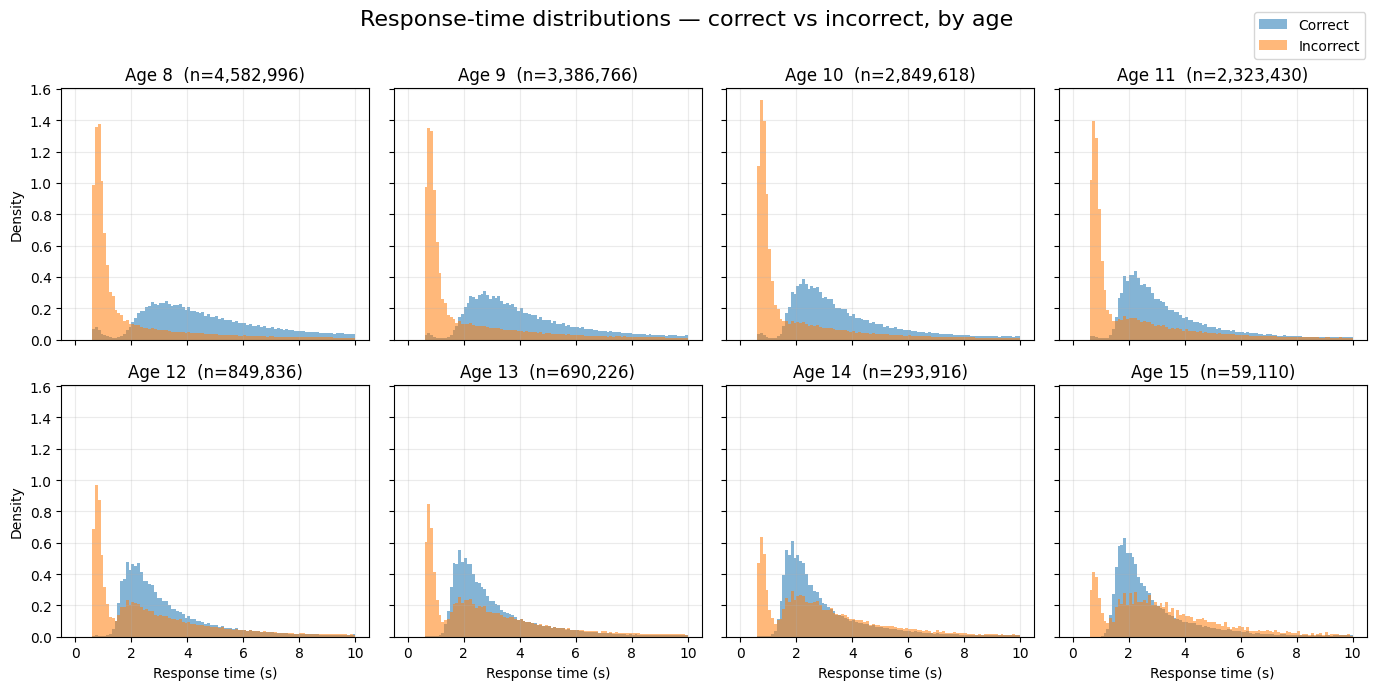

In [9]:
# ============================================================
# RT distributions — correct vs incorrect
# One single figure, one panel per age (4 rows x 2 columns)
# ============================================================

import math

HIST_BIN_WIDTH = 0.1
MAX_RT_HIST = 10.0

bins = np.arange(
    0,
    MAX_RT_HIST + HIST_BIN_WIDTH,
    HIST_BIN_WIDTH
)

ages = np.arange(8, 16)

NCOLS = 4
NROWS = math.ceil(len(ages) / NCOLS)


fig, axes = plt.subplots(
    nrows=NROWS,
    ncols=NCOLS,
    figsize=(14, 3.5 * NROWS),
    sharex=True,
    sharey=True
)

axes = np.atleast_1d(axes).flatten()


for i, (ax, age) in enumerate(zip(axes, ages)):

    age_df = a998[
        (a998["classroom_course_age"] == age)
        & (a998["rt_seconds"] <= MAX_RT_HIST)
    ]

    correct_rt = age_df.loc[
        age_df["is_correct"] == 1,
        "rt_seconds"
    ]

    incorrect_rt = age_df.loc[
        age_df["is_correct"] == 0,
        "rt_seconds"
    ]

    ax.hist(
        correct_rt,
        bins=bins,
        alpha=0.55,
        label="Correct",
        density=True
    )

    ax.hist(
        incorrect_rt,
        bins=bins,
        alpha=0.55,
        label="Incorrect",
        density=True
    )

    ax.set_title(
        f"Age {age}  (n={len(age_df):,})"
    )

    # Axis labels only on the outer panels, to avoid repeating
    # the same text eight times
    if i % NCOLS == 0:
        ax.set_ylabel("Density")

    if i >= len(ages) - NCOLS:
        ax.set_xlabel("Response time (s)")

    ax.grid(alpha=0.25)


# ------------------------------------------------------------
# Hide unused panels if the grid is larger than the age list
# ------------------------------------------------------------

for j in range(len(ages), len(axes)):
    axes[j].axis("off")


# ------------------------------------------------------------
# Shared legend + title
# ------------------------------------------------------------

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.99, 0.985)
)

fig.suptitle(
    "Response-time distributions — correct vs incorrect, by age",
    fontsize=16
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

plt.tight_layout(rect=[0, 0, 1, 0.97])

fig.savefig(
    PLOTS_DIR / "rt_distribution_correct_incorrect_all_ages.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

Yes! Incorrect responses are bimodal! We are clearly seeing the fact answers region! Our goal is to define a threshold from where we can filter answers. Let's check if this region is stable across facts.

Skipping age 15, 2×2: only 30 incorrect attempts
Skipping age 15, 3×4: only 23 incorrect attempts
Skipping age 15, 3×8: only 47 incorrect attempts
Skipping age 15, 5×5: only 35 incorrect attempts
Skipping age 15, 8×9: only 40 incorrect attempts


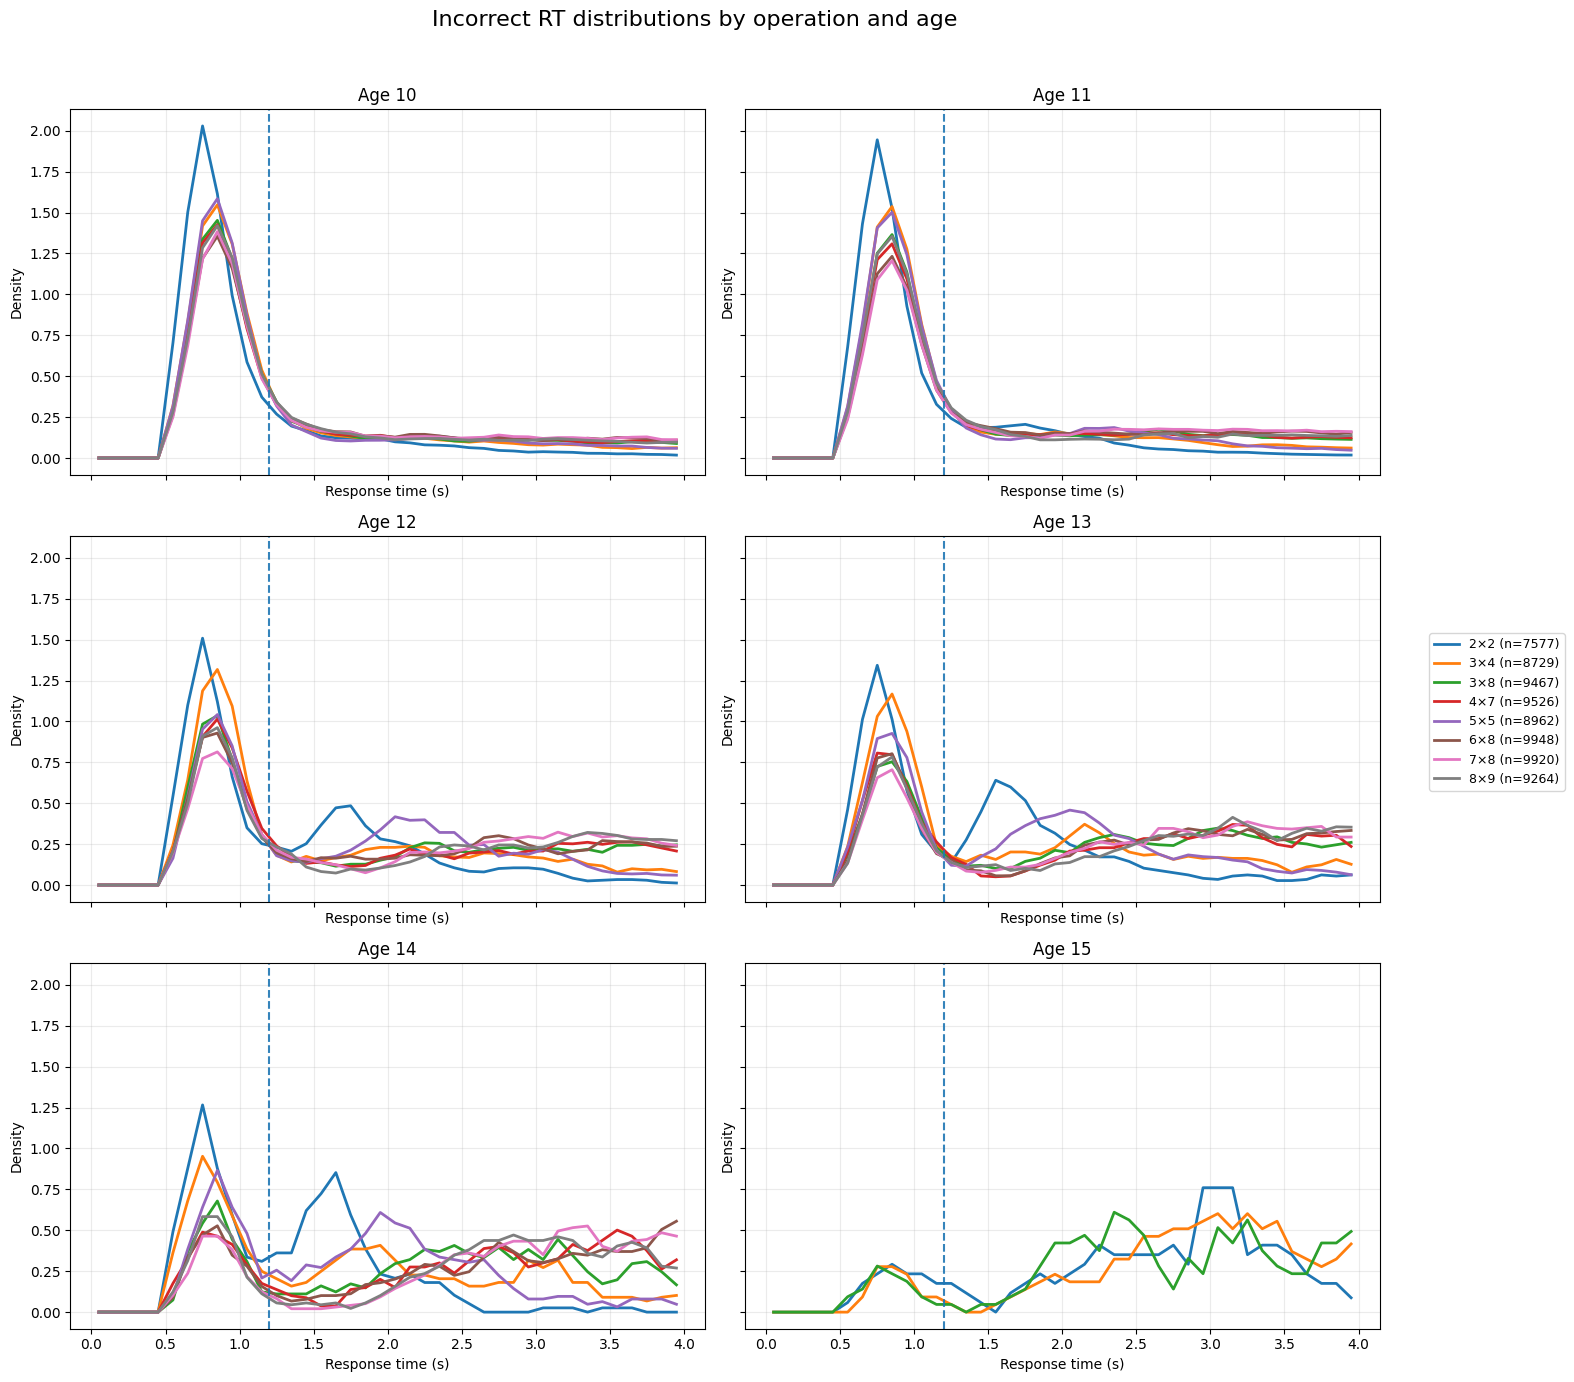

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ============================================================
# Parameters
# ============================================================

OPERATIONS_TO_PLOT = [
    (2, 2),
    (3, 4),
    (3, 8),
    (4, 7),
    (5, 5),
    (6, 8),
    (7, 8),
    (8, 9),
]

BIN_WIDTH = 0.1            # 100 ms
MAX_RT_PLOT = 4.0
MIN_INCORRECT_ATTEMPTS = 50
SMOOTHING_WINDOW = 3
VERTICAL_LINE_X = 1.2

# If you want all ages in the data:
AGES_TO_PLOT = np.arange(10, 16)

# Optional: if you only want a subset, replace the line above with e.g.
# AGES_TO_PLOT = [8, 9, 10, 11, 12, 13, 14, 15]


# ============================================================
# Prepare incorrect-only data
# ============================================================

plot_data = a998[
    a998["classroom_course_age"].isin(AGES_TO_PLOT)
    & (a998["is_correct"] == 0)
    & a998["rt_seconds"].notna()
    & (a998["rt_seconds"] >= 0)
    & (a998["rt_seconds"] <= MAX_RT_PLOT)
].copy()

plot_data["operation"] = (
    plot_data["factor_1"].astype(int).astype(str)
    + "×"
    + plot_data["factor_2"].astype(int).astype(str)
)


# ============================================================
# Build density curves
# ============================================================

bin_edges = np.arange(0, MAX_RT_PLOT + BIN_WIDTH, BIN_WIDTH)
bin_centers = bin_edges[:-1] + BIN_WIDTH / 2

curves = []

for age in AGES_TO_PLOT:
    for a, b in OPERATIONS_TO_PLOT:

        op_label = f"{a}×{b}"

        op_df = plot_data[
            (plot_data["classroom_course_age"] == age)
            & (plot_data["factor_1"] == a)
            & (plot_data["factor_2"] == b)
        ].copy()

        n_attempts = len(op_df)

        if n_attempts < MIN_INCORRECT_ATTEMPTS:
            print(f"Skipping age {age}, {op_label}: only {n_attempts} incorrect attempts")
            continue

        counts, _ = np.histogram(op_df["rt_seconds"], bins=bin_edges)

        # Normalize to density-like curve
        density = counts / (counts.sum() * BIN_WIDTH)

        curve_df = pd.DataFrame({
            "age": age,
            "operation": op_label,
            "rt_bin_center": bin_centers,
            "density": density,
            "n_attempts": n_attempts
        })

        if SMOOTHING_WINDOW > 1:
            curve_df["density"] = (
                curve_df["density"]
                .rolling(SMOOTHING_WINDOW, center=True, min_periods=1)
                .mean()
            )

        curves.append(curve_df)

if len(curves) == 0:
    raise ValueError("No age/operation combination had enough incorrect attempts to plot.")

curves_df = pd.concat(curves, ignore_index=True)


# ============================================================
# Multi-panel plot: one panel per age
# ============================================================

n_ages = len(AGES_TO_PLOT)
ncols = 2
nrows = math.ceil(n_ages / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(14, 4.5 * nrows),
    sharex=True,
    sharey=True
)

# Flatten axes for easy iteration
if n_ages == 1:
    axes = np.array([axes])
axes = axes.flatten()

for ax, age in zip(axes, AGES_TO_PLOT):

    age_df = curves_df[curves_df["age"] == age]

    for op_label in age_df["operation"].unique():
        op_curve = age_df[age_df["operation"] == op_label]
        n_attempts = int(op_curve["n_attempts"].iloc[0])

        ax.plot(
            op_curve["rt_bin_center"],
            op_curve["density"],
            linewidth=2,
            label=f"{op_label} (n={n_attempts})"
        )

    ax.axvline(
        VERTICAL_LINE_X,
        linestyle="--",
        linewidth=1.5,
        alpha=0.9
    )

    ax.set_title(f"Age {age}")
    ax.set_xlabel("Response time (s)")
    ax.set_ylabel("Density")
    ax.grid(alpha=0.25)

# Hide unused axes if grid is larger than number of ages
for j in range(len(AGES_TO_PLOT), len(axes)):
    axes[j].axis("off")

# Put legend only once, outside the panels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9
)

fig.suptitle(
    "Incorrect RT distributions by operation and age",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

fig.savefig(
    PLOTS_DIR / "incorrect_rt_by_operation_all_ages.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

Very interesting take! The rapid-random guessing part remains stable under operations and the real memory retrieval is modulated depending on the operation. This makes so much sense! Autopilot is the same thing regardless of the operation shown! On the other hand, remembering 2x2 is way easier than 6x8. 

### I have chosen to define the rapid guessers as **all answers under 1.2 s that are incorrect**

## Fluency zone

In [11]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Paths
# ============================================================

HERE = Path.cwd()

ROOT = HERE
while not (ROOT / "databricks_connector.py").exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError(
            "databricks_connector.py not found in any parent directory"
        )
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

from cached_query import cached_query


QUERY_DIR = HERE / "queries"
CACHE_DIR = HERE / "cache"
PLOTS_DIR = HERE / "plots"

CACHE_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)


# ============================================================
# Load data
# ============================================================

SQL_PATH = QUERY_DIR / "fluency_sample_data.sql"

fluency_raw = cached_query(
    SQL_PATH,
    CACHE_DIR
)

print(f"Loaded {len(fluency_raw):,} attempts")
print(fluency_raw.shape)
display(fluency_raw.head())

Loaded 14,400,000 attempts
(14400000, 13)


,region,academic_year_id,classroom_course_age,student_uuid,elementary_fluency_session_uuid,elementary_fluency_attempt_uuid,operation_raw,factor_1,factor_2,attempt_no,attempt_result,is_correct,rt_seconds
0,BR,BR_2025,8.0,018DC24CBDC272CDAA78D84DA568D61C,B1A35B8155084D7B8C3C23ACEC1E2F31,5C4FCCC6F31B4364AE0A2C56B2187B46,1 X 1,1,1,2,Incorrect,0,4.602
1,BR,BR_2025,8.0,018DF9EF367D73F5BFCAE1D76F3801A2,861EE355EE7246F59FBC420D2F88C6E5,E053BFDAE26642C0ABB4894C6BEC4F77,1 X 1,1,1,1,Correct at first,1,5.582
2,BR,BR_2025,8.0,E9D1D0467C9A480696BFB56C173B824E,C7F48141FB984DF5AF651EA6DE74A77C,13C32FE6849046DCB84B9E40F7E38468,1 X 1,1,1,1,Correct at first,1,3.285
3,BR,BR_2025,8.0,55D02BC3A94145A58C0E96E263D336FF,6000BE1F798B44BAB8514E3E541BA9F6,08B831B30D5D4CF9ACFCFA1AA88A867F,1 X 1,1,1,1,Correct at first,1,6.850
4,BR,BR_2025,8.0,1C8573033852413E9602683173D28816,6BAE484159E642D68FE6EF650E7CDBB4,2C6E44E66C9243CFB22305F6761E7272,1 X 1,1,1,1,Correct at first,1,3.941


It looks like way fewer students take random-rapid guesses in the fluency zone!

Let's compare the two activity types in number of disengaged students

In [12]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Paths
# ============================================================

HERE = Path.cwd()

ROOT = HERE
while not (ROOT / "databricks_connector.py").exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError(
            "databricks_connector.py not found in any parent directory"
        )
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

from cached_query import cached_query


QUERY_DIR = HERE / "queries"
CACHE_DIR = HERE / "cache"
PLOTS_DIR = HERE / "plots"

CACHE_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)


# ============================================================
# Load F2 and Fluency
# ============================================================

a998_raw = cached_query(
    QUERY_DIR / "a998_sample_data.sql",
    CACHE_DIR
)

fluency_raw = cached_query(
    QUERY_DIR / "fluency_sample_data.sql",
    CACHE_DIR
)

print(f"F2:      {len(a998_raw):,} attempts")
print(f"Fluency: {len(fluency_raw):,} attempts")


# ============================================================
# Parameters
# ============================================================

AGES_TO_PLOT = np.arange(8, 16)
RANDOM_GUESS_THRESHOLD = 1.2


# ============================================================
# Function
# ============================================================

def random_guess_by_age(attempts_df, activity_name):

    attempts = attempts_df[
        attempts_df["classroom_course_age"].isin(AGES_TO_PLOT)
        & attempts_df["rt_seconds"].notna()
        & attempts_df["is_correct"].notna()
    ].copy()

    # Random guess:
    # incorrect AND RT <= 1.2 s
    attempts["is_random_guess"] = (
        (attempts["is_correct"] == 0)
        & (attempts["rt_seconds"] <= RANDOM_GUESS_THRESHOLD)
    )

    summary = (
        attempts
        .groupby("classroom_course_age")
        .agg(
            total_attempts=("is_random_guess", "size"),
            random_guess_attempts=("is_random_guess", "sum")
        )
        .reset_index()
    )

    summary["random_guess_pct"] = (
        100
        * summary["random_guess_attempts"]
        / summary["total_attempts"]
    )

    summary["activity"] = activity_name

    return summary


# ============================================================
# Calculate percentages
# ============================================================

f2_rg = random_guess_by_age(
    a998_raw,
    activity_name="F2"
)

fluency_rg = random_guess_by_age(
    fluency_raw,
    activity_name="Fluency"
)

rg_summary = pd.concat(
    [f2_rg, fluency_rg],
    ignore_index=True
)


# ============================================================
# Show full table
# ============================================================

display(
    rg_summary[
        [
            "activity",
            "classroom_course_age",
            "total_attempts",
            "random_guess_attempts",
            "random_guess_pct"
        ]
    ]
    .sort_values(
        ["classroom_course_age", "activity"]
    )
)


# ============================================================
# Comparison table: F2 vs Fluency
# ============================================================

rg_pivot = (
    rg_summary
    .pivot(
        index="classroom_course_age",
        columns="activity",
        values="random_guess_pct"
    )
    .reset_index()
)

rg_pivot.columns.name = None

display(
    rg_pivot.round(2)
)

F2:      16,894,141 attempts
Fluency: 14,400,000 attempts


,activity,classroom_course_age,total_attempts,random_guess_attempts,random_guess_pct
0,F2,8.0,5348903,1630633,30.485372
8,Fluency,8.0,2708246,9309,0.343728
1,F2,9.0,3848680,776612,20.178659
9,Fluency,9.0,3958540,16654,0.420711
2,F2,10.0,3144473,590592,18.781907
10,Fluency,10.0,4016039,18146,0.451838
3,F2,11.0,2527705,314349,12.436143
11,Fluency,11.0,3638272,14259,0.391917
4,F2,12.0,911946,47377,5.195154
12,Fluency,12.0,360,1,0.277778


,classroom_course_age,F2,Fluency
0,8.0,30.49,0.34
1,9.0,20.18,0.42
2,10.0,18.78,0.45
3,11.0,12.44,0.39
4,12.0,5.20,0.28
5,13.0,3.33,NaN
6,14.0,2.04,0.00
7,15.0,1.21,0.00


In [13]:
# ============================================================
# Percentage of students classified as random guessers
# Random guess attempt = incorrect AND RT <= 1.2 s
# Random guesser = >50% of their attempts are random guesses
# ============================================================

AGES_TO_PLOT = np.arange(8, 16)

RT_THRESHOLD = 1.5
STUDENT_RG_THRESHOLD = 0.50
MIN_ATTEMPTS_PER_STUDENT = 5


def random_guess_students_by_age(attempts_df, activity_name):

    attempts = attempts_df[
        attempts_df["classroom_course_age"].isin(AGES_TO_PLOT)
        & attempts_df["student_uuid"].notna()
        & attempts_df["rt_seconds"].notna()
        & attempts_df["is_correct"].notna()
    ].copy()

    # --------------------------------------------------------
    # Flag individual random-guess attempts
    # --------------------------------------------------------

    attempts["is_random_guess"] = (
        (attempts["is_correct"] == 0)
        & (attempts["rt_seconds"] <= RT_THRESHOLD)
    )

    # --------------------------------------------------------
    # Calculate random-guess rate for each student
    # within each age
    # --------------------------------------------------------

    student_summary = (
        attempts
        .groupby(
            ["classroom_course_age", "student_uuid"],
            observed=True
        )
        .agg(
            total_attempts=("is_random_guess", "size"),
            random_guess_attempts=("is_random_guess", "sum")
        )
        .reset_index()
    )

    student_summary["random_guess_rate"] = (
        student_summary["random_guess_attempts"]
        / student_summary["total_attempts"]
    )

    # --------------------------------------------------------
    # Require a minimum number of observations
    # --------------------------------------------------------

    student_summary = student_summary[
        student_summary["total_attempts"] >= MIN_ATTEMPTS_PER_STUDENT
    ].copy()

    # Strictly MORE than 50%
    student_summary["is_random_guesser"] = (
        student_summary["random_guess_rate"] > STUDENT_RG_THRESHOLD
    )

    # --------------------------------------------------------
    # Percentage of students classified as random guessers
    # --------------------------------------------------------

    age_summary = (
        student_summary
        .groupby(
            "classroom_course_age",
            observed=True
        )
        .agg(
            n_students=("student_uuid", "size"),
            n_random_guessers=("is_random_guesser", "sum")
        )
        .reset_index()
    )

    age_summary["random_guesser_pct"] = (
        100
        * age_summary["n_random_guessers"]
        / age_summary["n_students"]
    )

    age_summary["activity"] = activity_name

    return age_summary, student_summary


# ============================================================
# F2
# ============================================================

f2_student_rg, f2_student_detail = random_guess_students_by_age(
    a998_raw,
    activity_name="F2"
)


# ============================================================
# Fluency
# ============================================================

fluency_student_rg, fluency_student_detail = random_guess_students_by_age(
    fluency_raw,
    activity_name="Fluency"
)


# ============================================================
# Combine
# ============================================================

student_rg_summary = pd.concat(
    [
        f2_student_rg,
        fluency_student_rg
    ],
    ignore_index=True
)


display(
    student_rg_summary[
        [
            "activity",
            "classroom_course_age",
            "n_students",
            "n_random_guessers",
            "random_guesser_pct"
        ]
    ]
    .sort_values(
        ["classroom_course_age", "activity"]
    )
    .round(2)
)

,activity,classroom_course_age,n_students,n_random_guessers,random_guesser_pct
0,F2,8.0,126947,21670,17.07
8,Fluency,8.0,100563,18,0.02
1,F2,9.0,144740,17057,11.78
9,Fluency,9.0,101204,15,0.01
2,F2,10.0,138228,14157,10.24
10,Fluency,10.0,95167,26,0.03
3,F2,11.0,100503,6929,6.89
11,Fluency,11.0,82754,13,0.02
4,F2,12.0,41242,1262,3.06
12,Fluency,12.0,17,0,0.00


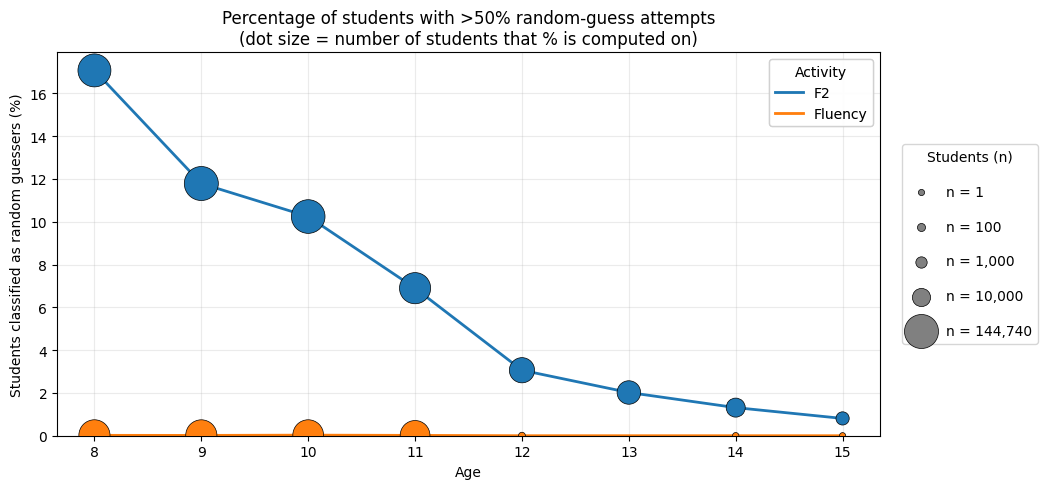

In [14]:
# ============================================================
# Plot
# Marker size encodes n_students -- the total number of students
# behind each percentage (the "100%" denominator). sqrt-scaled for
# perceptually correct area, then min-max mapped onto a fixed
# pixel-area range so a thin, unreliable N (e.g. Fluency age 15,
# n=1) reads as visually small next to a solid one (e.g. F2 age 9,
# n=144,740) instead of the two looking equally trustworthy.
# ============================================================

SIZE_MIN = 20     # marker area (points^2) for the smallest n_students
SIZE_MAX = 600    # marker area (points^2) for the largest n_students


def n_to_size(n, n_min, n_max):
    """Sqrt-scale n_students (perceptual area), then map to [SIZE_MIN, SIZE_MAX]."""
    n = np.asarray(n, dtype=float)
    sqrt_n = np.sqrt(n)
    sqrt_min, sqrt_max = np.sqrt(n_min), np.sqrt(n_max)
    if sqrt_max == sqrt_min:
        return np.full_like(sqrt_n, (SIZE_MIN + SIZE_MAX) / 2)
    frac = (sqrt_n - sqrt_min) / (sqrt_max - sqrt_min)
    return SIZE_MIN + frac * (SIZE_MAX - SIZE_MIN)


# Shared scale across BOTH activities, so a dot's size means the same
# thing whichever line it sits on.
n_min = student_rg_summary["n_students"].min()
n_max = student_rg_summary["n_students"].max()

fig, ax = plt.subplots(figsize=(9, 5))

for activity in ["F2", "Fluency"]:

    plot_df = student_rg_summary[
        student_rg_summary["activity"] == activity
    ].sort_values("classroom_course_age")

    # Trend line first, no built-in markers -- the sized dots are
    # drawn on top with scatter() so their size can vary per point.
    line, = ax.plot(
        plot_df["classroom_course_age"],
        plot_df["random_guesser_pct"],
        linewidth=2,
        label=activity,
        zorder=2
    )

    sizes = n_to_size(
        plot_df["n_students"],
        n_min,
        n_max
    )

    ax.scatter(
        plot_df["classroom_course_age"],
        plot_df["random_guesser_pct"],
        s=sizes,
        color=line.get_color(),
        edgecolor="black",
        linewidth=0.5,
        zorder=3
    )

ax.set_xlabel("Age")
ax.set_ylabel("Students classified as random guessers (%)")

ax.set_title(
    "Percentage of students with >50% random-guess attempts\n"
    "(dot size = number of students that % is computed on)"
)

ax.set_xticks(AGES_TO_PLOT)
ax.set_ylim(bottom=0)

ax.grid(alpha=0.25)

# --------------------------------------------------------
# Two separate legends: activity (color) and n_students (size).
# ax.legend() would overwrite the first call if not "kept alive"
# with add_artist, so the activity legend is added explicitly.
# --------------------------------------------------------

activity_legend = ax.legend(loc="upper right", title="Activity")
ax.add_artist(activity_legend)

# A few representative n_students values spanning the real range
# in the data (nice round numbers, clipped to [n_min, n_max]).
legend_n_values = sorted(set(
    int(v) for v in [n_min, 10, 100, 1_000, 10_000, 100_000, n_max]
    if n_min <= v <= n_max
))

# Keep at most 5 reference dots so the legend stays readable
if len(legend_n_values) > 5:
    idx = np.linspace(0, len(legend_n_values) - 1, 5).round().astype(int)
    legend_n_values = [legend_n_values[i] for i in sorted(set(idx))]

size_handles = [
    ax.scatter(
        [], [],
        s=n_to_size([n], n_min, n_max),
        color="gray",
        edgecolor="black",
        linewidth=0.5,
        label=f"n = {n:,}"
    )
    for n in legend_n_values
]

fig.legend(
    handles=size_handles,
    title="Students (n)",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    labelspacing=1.5,
    frameon=True
)

plt.tight_layout()

fig.savefig(
    PLOTS_DIR / "random_guessers_percentage_by_age_f2_vs_fluency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

In [15]:
a = a998_raw.loc[a998_raw["statement_idx"] >= 1]      # idx 0 fora, veure sota

print(a.groupby("academic_year_id")["rt_seconds"]
       .agg(n="size", minim="min",
            p001=lambda s: s.quantile(0.001),
            p01=lambda s: s.quantile(0.01),
            pct_sota_061=lambda s: 100 * (s < 0.61).mean())
       .sort_values("pct_sota_061", ascending=False)
       .round(3))

# el 0,615 és un valor exacte o un esborrall?
print(a.loc[a["rt_seconds"].between(0.60, 0.63), "rt_seconds"].value_counts().head(15))

                        n  minim   p001    p01  pct_sota_061
academic_year_id                                            
CO-A_2025           10990  0.283  0.631  0.650         0.009
MX_2025            920718  0.167  0.633  0.666         0.001
MX_2024            704571  0.083  0.619  0.649         0.001
IT_2025            457530  0.133  0.634  0.669         0.000
ES_2025           5169191  0.083  0.633  0.667         0.000
ES_2022           2506545  0.117  0.618  0.650         0.000
ES_2024           4440204  0.117  0.618  0.650         0.000
ES_2023           1143241  0.273  0.619  0.650         0.000
CO-A_2026              85  0.649  0.657  0.732         0.000
BR_2024               770  0.700  0.738  1.607         0.000
BR_2025             17473  0.616  0.623  0.638         0.000
BR_2026               580  0.667  0.679  0.720         0.000
CL_2025             46964  0.616  0.617  0.649         0.000
CO-A_2024              55  0.667  0.669  0.685         0.000
EC-SI_2025         10310

A998    (ages 8-11):            13,142,810 attempts
Fluency (ages 8-11, attempt 1): 9,951,431 attempts


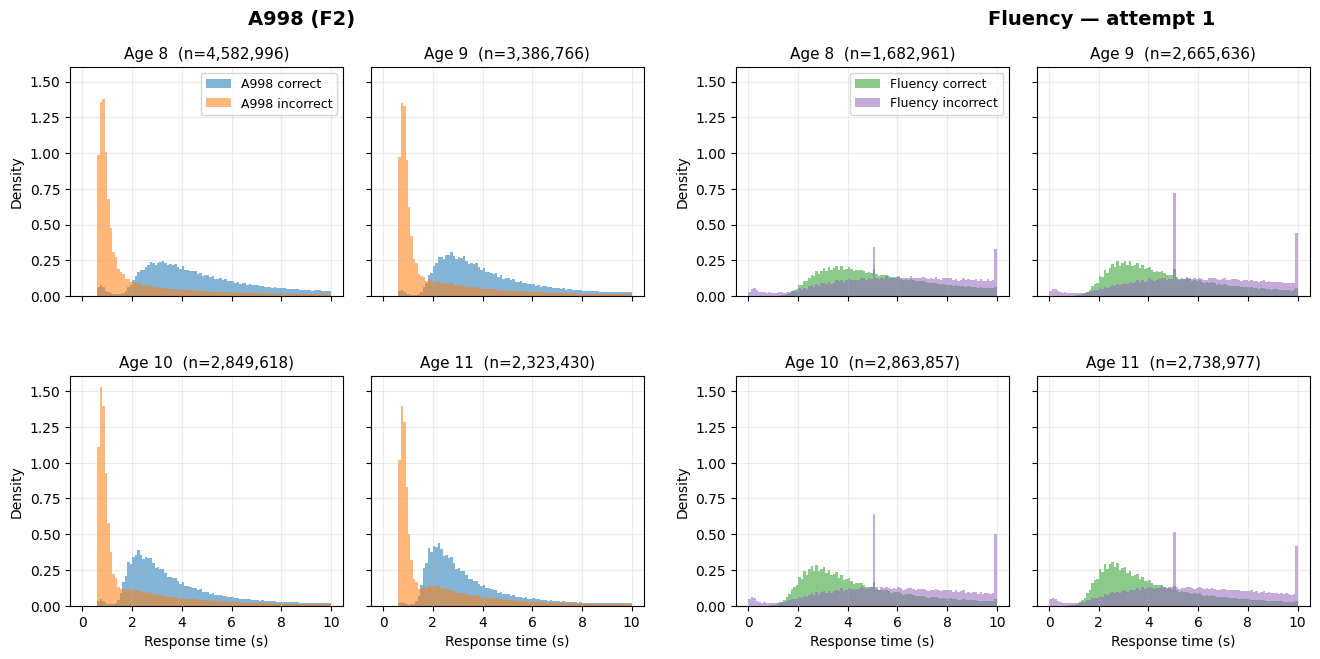

In [16]:
# ============================================================
# A998 (F2) vs Fluency — RT distributions, correct vs incorrect
# Ages 8-11 only
#
# Layout: one figure, two blocks side by side.
#   Left  block (2x2 square of ages) = A998, original blue/orange
#   Right block (2x2 square of ages) = Fluency, green/purple
#
# Fluency is restricted to attempt_no == 1, so both sides show a
# first (and only) exposure to the fact.
# x and y are shared across ALL eight panels, so panel heights are
# directly comparable between the two activities.
# ============================================================

AGES_TO_PLOT = [8, 9, 10, 11]

HIST_BIN_WIDTH = 0.10
MAX_RT_HIST = 10.0
RANDOM_GUESS_THRESHOLD = 1.2      # the criterion chosen above

bins = np.arange(
    0,
    MAX_RT_HIST + HIST_BIN_WIDTH,
    HIST_BIN_WIDTH
)

COLORS = {
    "A998": {"correct": "#1f77b4", "incorrect": "#ff7f0e"},
    "Fluency": {"correct": "#2ca02c", "incorrect": "#9467bd"},
}


# ============================================================
# Data — reload from cache so the cell does not depend on
# whatever `data` happens to hold at this point in the notebook
# ============================================================

a998_raw = cached_query(
    QUERY_DIR / "a998_sample_data.sql",
    CACHE_DIR
)

fluency_raw = cached_query(
    QUERY_DIR / "fluency_sample_data.sql",
    CACHE_DIR
)


a998_data = a998_raw[
    a998_raw["classroom_course_age"].isin(AGES_TO_PLOT)
    & a998_raw["rt_seconds"].notna()
    & a998_raw["is_correct"].notna()
    & (a998_raw["rt_seconds"] >= 0)
    & (a998_raw["rt_seconds"] <= MAX_RT_HIST)
].copy()

fluency_data = fluency_raw[
    fluency_raw["classroom_course_age"].isin(AGES_TO_PLOT)
    & fluency_raw["rt_seconds"].notna()
    & fluency_raw["is_correct"].notna()
    & (fluency_raw["attempt_no"] == 1)
    & (fluency_raw["rt_seconds"] >= 0)
    & (fluency_raw["rt_seconds"] <= MAX_RT_HIST)
].copy()

print(f"A998    (ages 8-11):            {len(a998_data):,} attempts")
print(f"Fluency (ages 8-11, attempt 1): {len(fluency_data):,} attempts")


# ============================================================
# Figure skeleton: two 2x2 blocks side by side
# ============================================================

fig = plt.figure(figsize=(16, 7))

outer = fig.add_gridspec(
    nrows=1,
    ncols=2,
    wspace=0.16
)

blocks = [
    ("A998", a998_data, outer[0, 0]),
    ("Fluency", fluency_data, outer[0, 1]),
]

# First axes created is the reference for the shared x / y scales
ref_ax = None


for activity, block_df, outer_cell in blocks:

    inner = outer_cell.subgridspec(
        nrows=2,
        ncols=2,
        hspace=0.35,
        wspace=0.10
    )

    for i, age in enumerate(AGES_TO_PLOT):

        row, col = divmod(i, 2)

        ax = fig.add_subplot(
            inner[row, col],
            sharex=ref_ax,
            sharey=ref_ax
        )

        if ref_ax is None:
            ref_ax = ax

        age_df = block_df[
            block_df["classroom_course_age"] == age
        ]

        correct_rt = age_df.loc[
            age_df["is_correct"] == 1,
            "rt_seconds"
        ]

        incorrect_rt = age_df.loc[
            age_df["is_correct"] == 0,
            "rt_seconds"
        ]

        ax.hist(
            correct_rt,
            bins=bins,
            density=True,
            alpha=0.55,
            color=COLORS[activity]["correct"],
            label=f"{activity} correct"
        )

        ax.hist(
            incorrect_rt,
            bins=bins,
            density=True,
            alpha=0.55,
            color=COLORS[activity]["incorrect"],
            label=f"{activity} incorrect"
        )

        # The 1.2 s rapid-guess criterion
        # ax.axvline(
        #     RANDOM_GUESS_THRESHOLD,
        #     linestyle="--",
        #     linewidth=1.5,
        #     color="black",
        #     alpha=0.7
        # )

        ax.set_title(
            f"Age {age}  (n={len(age_df):,})",
            fontsize=11
        )

        # Labels only on the outer panels of each block
        if col == 0:
            ax.set_ylabel("Density")
        else:
            ax.tick_params(labelleft=False)

        if row == 1:
            ax.set_xlabel("Response time (s)")
        else:
            ax.tick_params(labelbottom=False)

        ax.grid(alpha=0.25)

        # One legend per block, on its first panel
        if i == 0:
            ax.legend(fontsize=9, loc="upper right")


# ============================================================
# Block headers + title
# ============================================================

fig.text(
    0.27, 0.94,
    "A998 (F2)",
    ha="center",
    fontsize=14,
    fontweight="bold"
)

fig.text(
    0.77, 0.94,
    "Fluency — attempt 1",
    ha="center",
    fontsize=14,
    fontweight="bold"
)

# fig.suptitle(
#     "Response-time distributions, correct vs incorrect — A998 vs Fluency, ages 8-11\n"
#     f"(dashed line = {RANDOM_GUESS_THRESHOLD} s rapid-guess criterion)",
#     fontsize=15,
#     y=1.0
# )


# ============================================================
# Save
# ============================================================

fig.savefig(
    PLOTS_DIR / "rt_distribution_a998_vs_fluency_ages_8_11.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)